# Sunrise/Sunset

Compute times of sunrise and sunset and solar noon for a location on earth.

Uses astropy and astroplan

In [7]:
import math

from astroplan import Observer
import astropy.units as u

from astropy.time import Time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter

import warnings
warnings.filterwarnings('ignore',category=UserWarning, append=True)

# convenience function - find index in array nearest value

def findNearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

## standard plot format

In [8]:
# aspect ratio

plotWide = True # wide-screen vs. letter sized

if plotWide:
    aspect = 16.0/9.0 # wide-screen
    aspStr = '16x9'
else:
    aspect = 4.0/3.0
    aspStr = '4x3'

#
# Don't change these unless you really need to (we never have)
#
# fPage is the horizontal fraction of the page occupied by the figure, default 1.0
#
# scaleFac is the LaTeX includegraphics scaling in units of \textwidth, default 1.0
#

fPage = 1.0
scaleFac = 0.85

# Text width in inches - don't change, this is defined by the print layout

textWidth = 6.0 # inches

# Graphic dimensions depending on bitmap or vector format (draft vs production)

figFmt = 'png'
dpi = 600
plotWidth = dpi*fPage*textWidth
plotHeight = plotWidth/aspect
axisFontSize = 10
labelFontSize = 8
lwidth = 0.5
axisPad = 5
wInches = fPage*textWidth # float(plotWidth)/float(dpi)
hInches = wInches/aspect  # float(plotHeight)/float(dpi)
    
# LaTeX is used throughout for markup of symbols, Times-Roman serif font

plt.rc('text', usetex=True)
plt.rc('font', **{'family':'serif','serif':['Times-Roman'],'weight':'bold','size':'16'})

# Font and line weight defaults for axes

matplotlib.rc('axes',linewidth=lwidth)
matplotlib.rcParams.update({'font.size':axisFontSize})

# axis and label padding

plt.rcParams['xtick.major.pad']=f'{axisPad}'
plt.rcParams['ytick.major.pad']=f'{axisPad}'
plt.rcParams['axes.labelpad'] = f'{axisPad}'

## Compute solar circumstances

Compute the times of sunrise, sunset, and solar noon for dates through a year for a location.

Note: This step is the slowest!

In [9]:
# Site information

siteName = "Columbus, OH"
siteLon = -83.0*u.deg
siteLat = 40.0*u.deg
siteElev = 210.0*u.m
siteTZ = "US/Eastern"
calcYear = "2025"

osu = Observer(longitude=siteLon,latitude=siteLat,elevation=siteElev,name=siteName,timezone=siteTZ)

t0 = Time(f"{calcYear}-01-01 17:00:00") # OSU local noon-ish on Jan 1 of the calculation year

jd0 = t0.jd

clockNoon = []
deltaNoon = []
clockSR = []
clockSS = []
clockSN = []

for day in range(366):
    jdNoon = jd0 + float(day)
    jdLMN = jdNoon - 0.5 # JD at local midnight
    
    
    tref = Time(jdNoon,format="jd")
    sunSet = osu.sun_set_time(tref, which="next") 
    sunRise = osu.sun_rise_time(tref,which="previous")

    solNoon = 0.5*(sunSet.jd + sunRise.jd)
    #print(sunRise,solNoon,sunSet)
    dayLight = 24.0*(sunSet.jd - sunRise.jd)
    
#    solNoon = osu.noon(tref,which="nearest",n_grid_points=600)
#    dNoon = 60.0*24*(solNoon.jd-jdNoon) # minutes
    
#    dateEST = sunRise.iso.split()[0]
#    ssTime = sunSet.iso.split()[1]
#    srTime = sunRise.iso.split()[1]
#    snTime = solNoon.iso.split()[1]
    
    dNoon = 24*60*(solNoon - jdNoon)
    clockNoon.append(jdNoon)
    deltaNoon.append(dNoon)
    clockSR.append(24.0*(sunRise.jd - jdLMN)) # hours
    clockSS.append(24.0*(sunSet.jd - jdLMN))  # hours
    clockSN.append(24.0*(solNoon - jdLMN))
        #clockSN.append(24.0*(solNoon.jd - jdLMN)) # hours


## Solstices, Equinoxes, and peri/aphelion

Source: USNO Earth's Seasons: https://aa.usno.navy.mil/data/Earth_Seasons



In [10]:
# hour arrays

SR = np.array(clockSR) # sunrise decimal standard time
SN = np.array(clockSN) # solar noon decimal standard time
SS = np.array(clockSS) # sunset decimal standard time
DL = SS - SR # length of the day

# equinoxes, solstices, perihelion and aphelion for the year of interest
#   Source: USNO, times are UTC

'''
tPeri = Time("2026-01-03 17:15:00")
tSE = Time("2026-03-20 14:46:00")
tSS = Time("2026-06-21 08:24:00")
tApo = Time("2026-07-06 17:30:00")
tAE = Time("2026-09-23 00:05:00")
tWS = Time("2026-12-21 20:50:00")
'''

tPeri= Time("2025-01-04 13:28:00")
tSE = Time("2025-03-20 09:01:00")
tSS = Time("2025-06-21 02:42:00")
tApo = Time("2025-07-03 19:55:00")
tAE = Time("2025-09-22 18:19:00")
tWS = Time("2025-12-21 15:03:00")


## Solar vs. Clock Noon

Plot the difference between solar and clock noon observed from `siteName` reckoned for timezone `siteTZ`.
time.

Mean offset = 32.001 minutes, range: 15.318 to 46.451 minutes


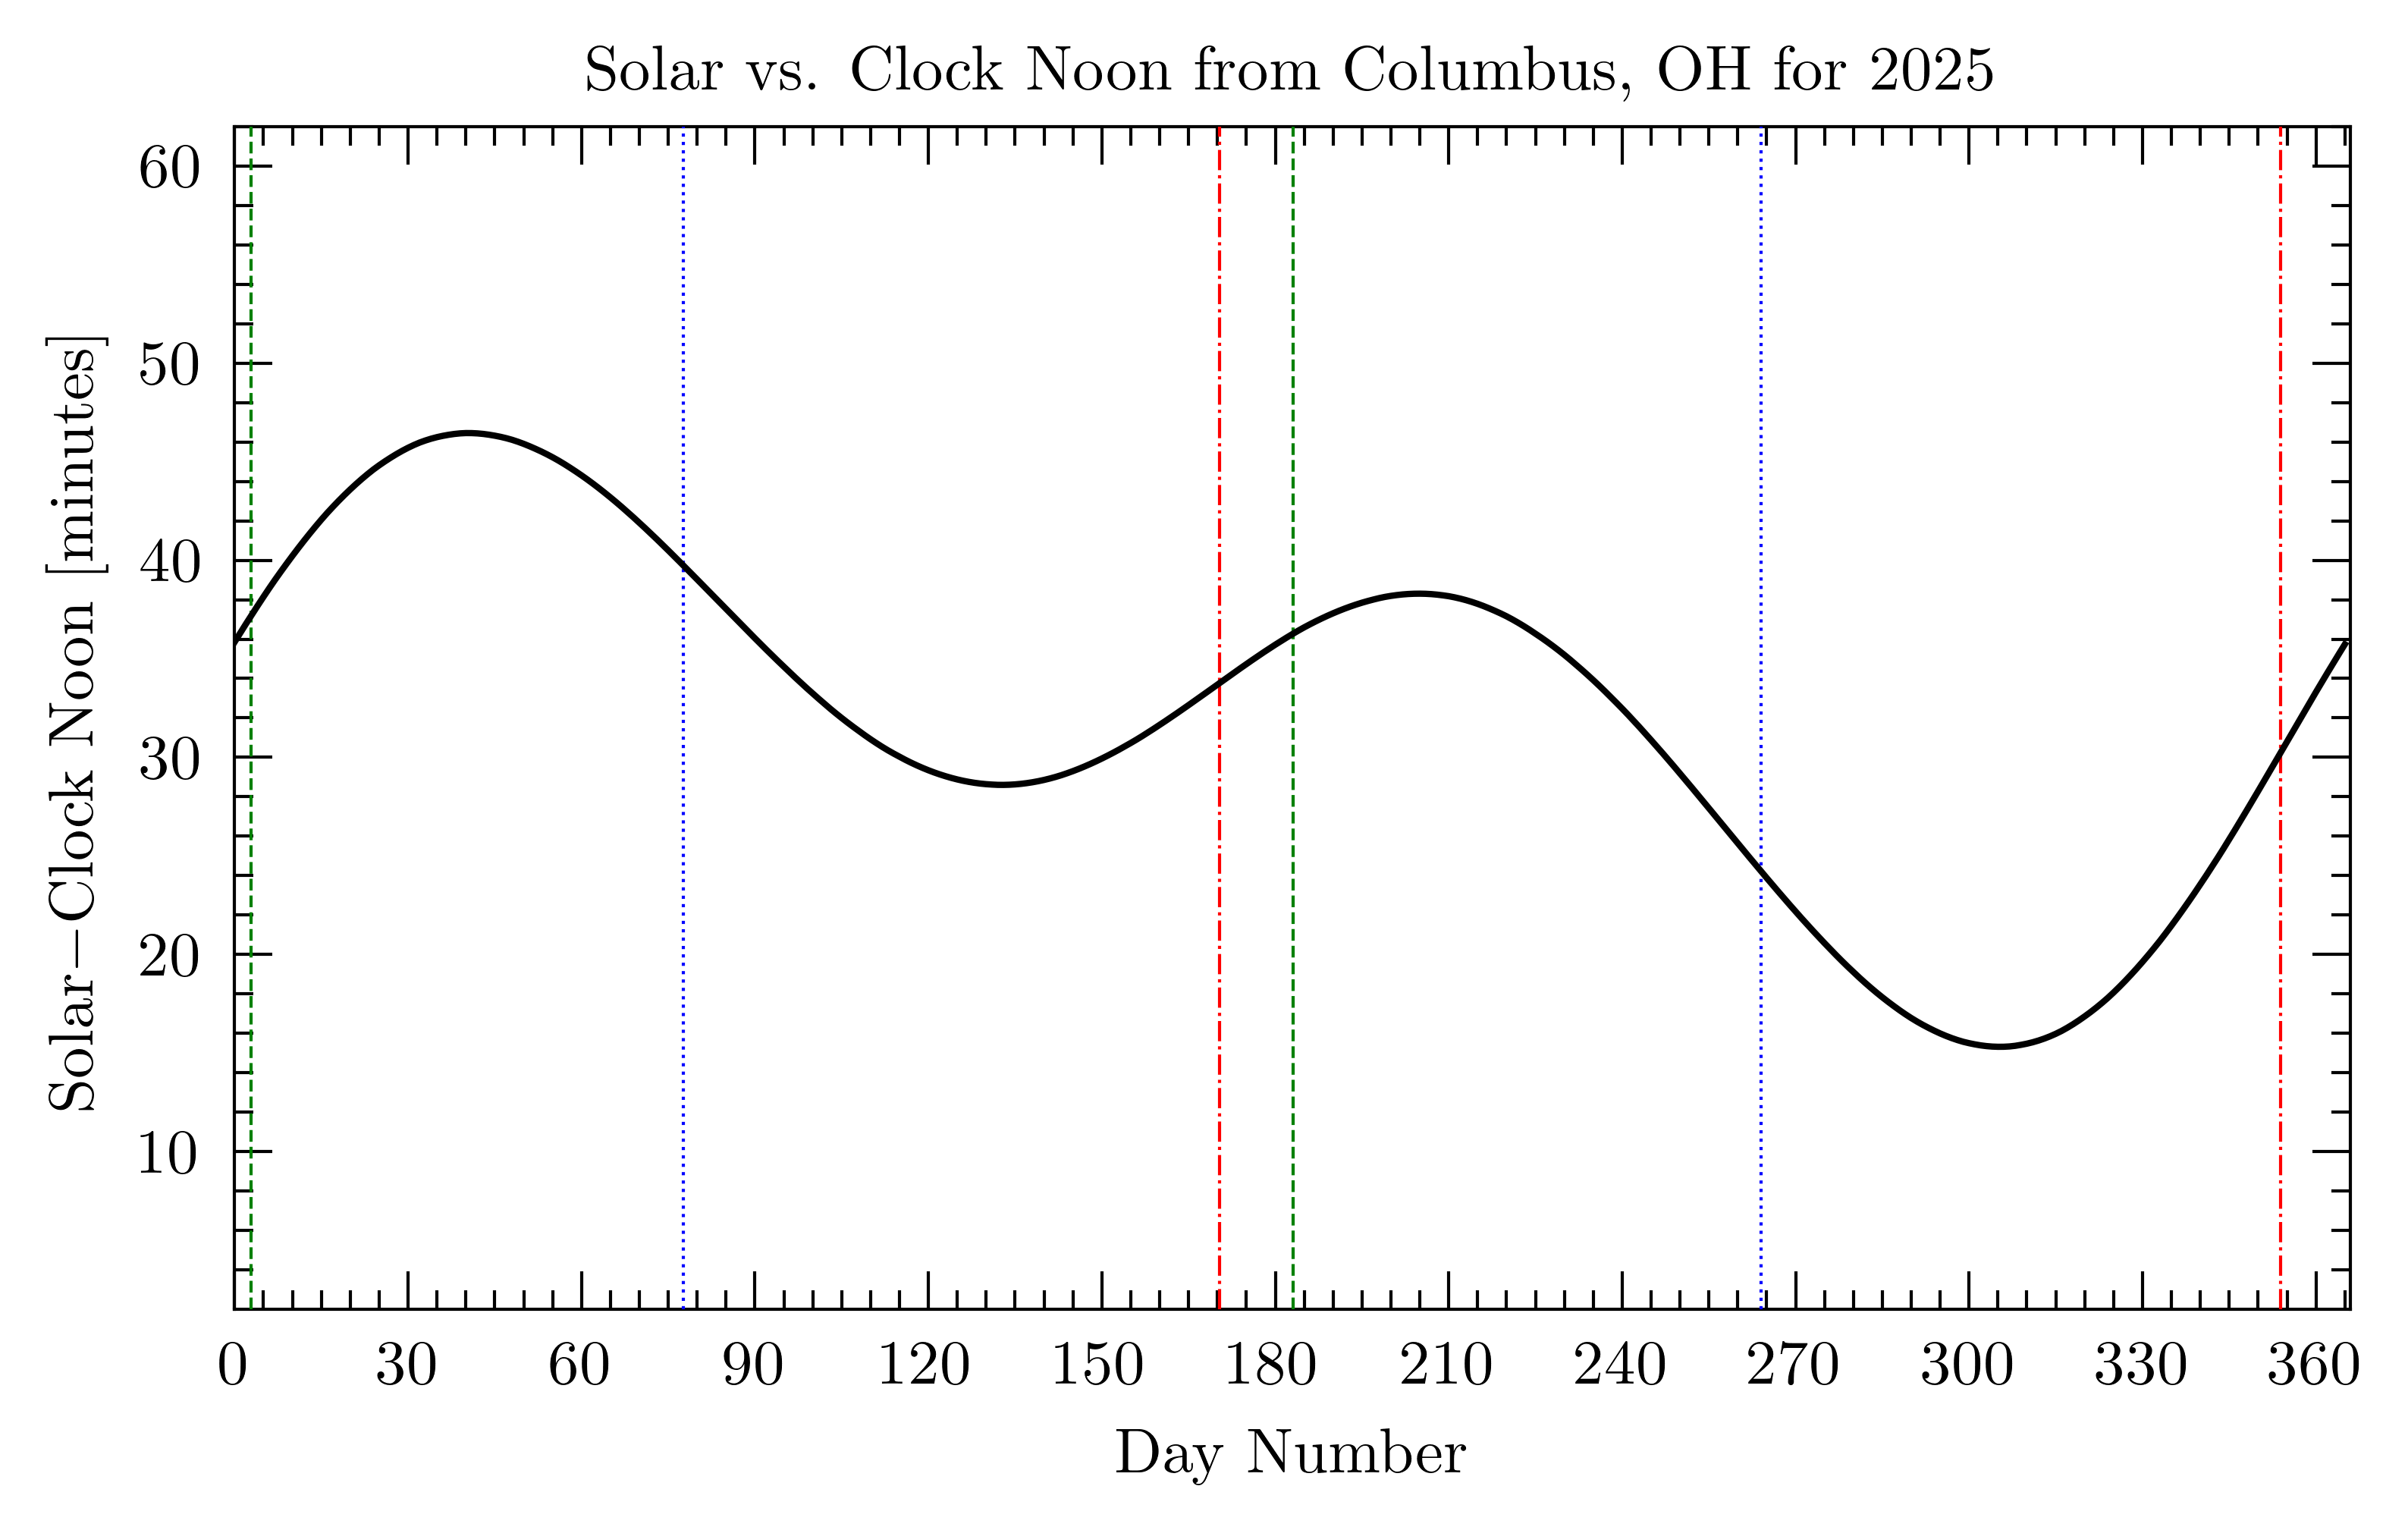

In [11]:
plotFile = f'MeanSolarTime_{siteName}{calcYear}.png'

# axis limits

calDay = clockNoon - clockNoon[0]

dMin = 0.0  # days
dMax = 366. # days
noonMin = np.mean(deltaNoon) - 30.0
noonMax = np.mean(deltaNoon) + 30.0

# minor stats

meanOff = np.mean(deltaNoon)
minOff = np.min(deltaNoon)
maxOff = np.max(deltaNoon)
print(f'Mean offset = {meanOff:.3f} minutes, range: {minOff:.3f} to {maxOff:.3f} minutes')

# do it

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=6,width=lwidth,which='major',direction='in',top=True,right=True)
ax.tick_params('both',length=3,width=lwidth,which='minor',direction='in',top=True,right=True)

ax.set_xlim(dMin,dMax)
ax.xaxis.set_major_locator(MultipleLocator(30))
ax.xaxis.set_minor_locator(MultipleLocator(5))
ax.set_xlabel(r'Day Number',fontsize=axisFontSize)

ax.set_ylim(noonMin,noonMax)
ax.yaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_minor_locator(MultipleLocator(2))
ax.set_ylabel(r'Solar$-$Clock Noon [minutes]',fontsize=axisFontSize)

plt.title(f'Solar vs. Clock Noon from {siteName} for {calcYear}',fontsize=axisFontSize)

plt.plot(calDay,deltaNoon,'-',color='black',lw=1,zorder=9)

# annotate with seasons and apsides

aps = [tPeri.jd-jd0,tApo.jd-jd0]
equi = [tSE.jd-jd0,tAE.jd-jd0]
sols = [tSS.jd-jd0,tWS.jd-jd0]

plt.vlines(aps,noonMin,noonMax,ls=['--'],colors=['green'],lw=0.5,zorder=8)
plt.vlines(equi,noonMin,noonMax,ls=[':'],colors=['blue'],lw=0.5,zorder=8)
plt.vlines(sols,noonMin,noonMax,ls=['-.'],colors=['red'],lw=0.5,zorder=8)

# make the plot

plt.savefig(plotFile,facecolor='white',bbox_inches='tight')
plt.show()

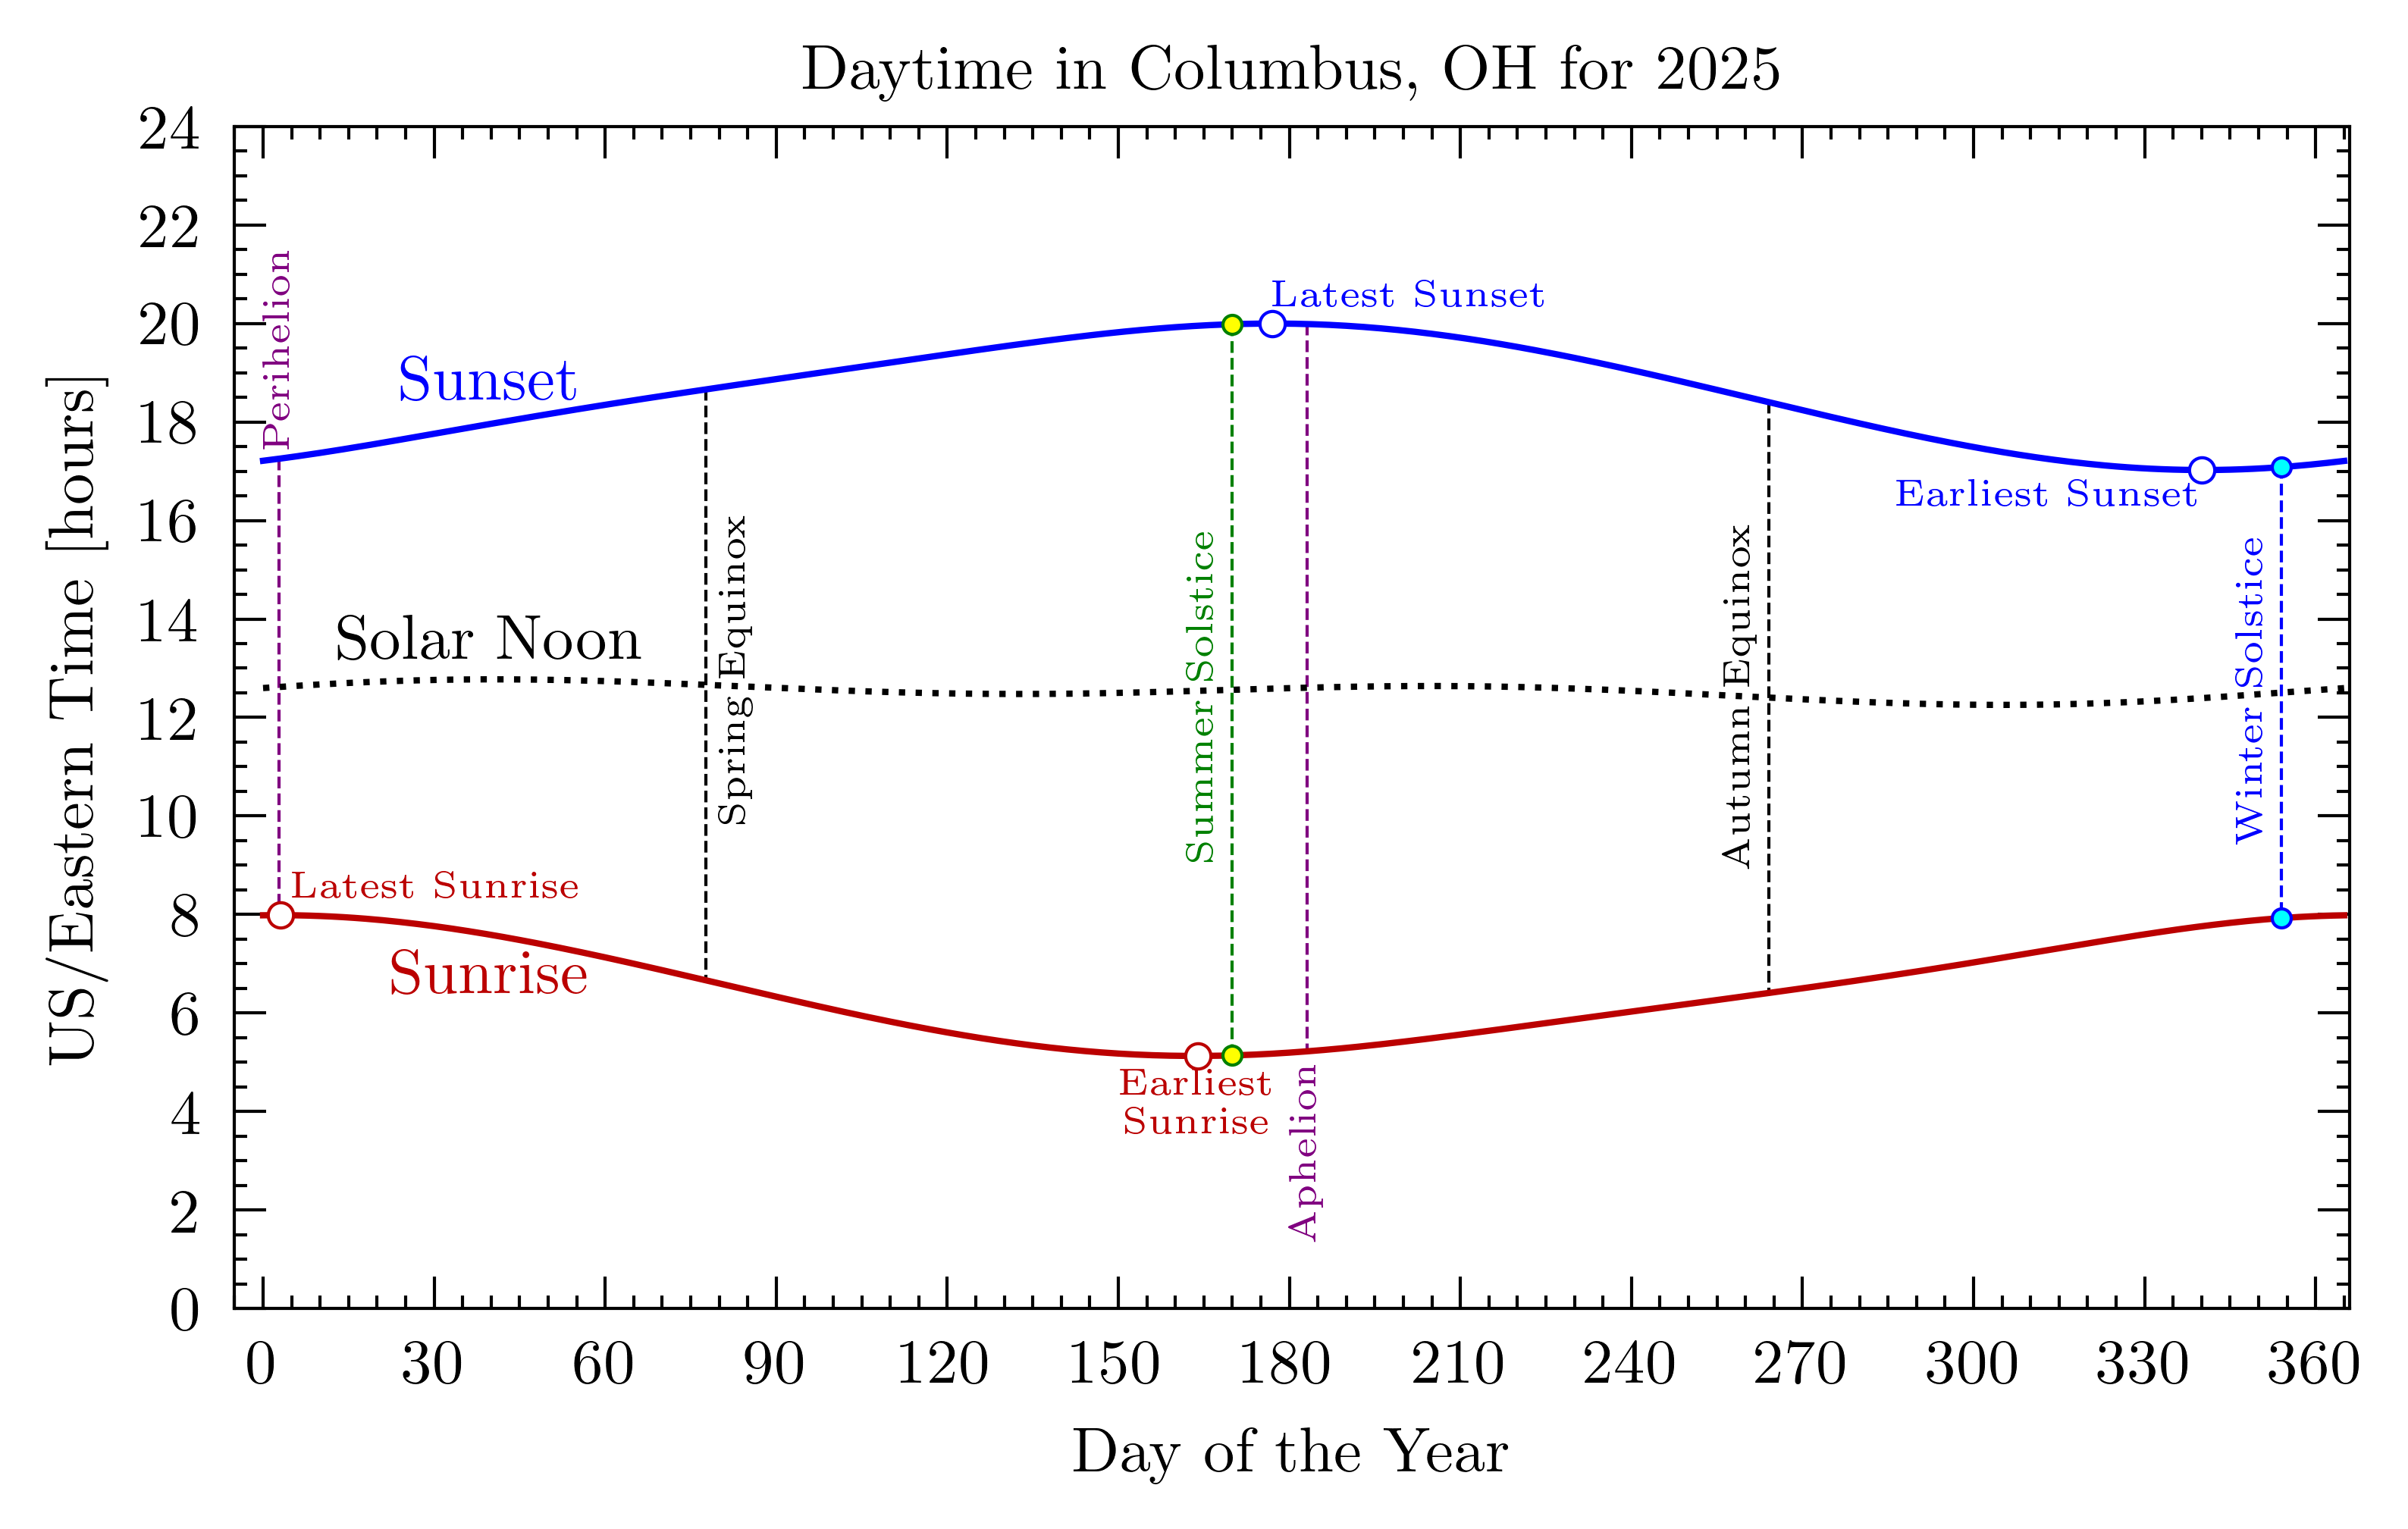

In [12]:
plotFile = f'Daytime_{siteName}{calcYear}.png'

# axis limits

calDay = clockNoon - clockNoon[0]

dMin = -5  # days
dMax = 366. # days
tMin = 0
tMax = 24

# do it

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=5,width=lwidth,which='major',direction='in',top=True,right=True)
ax.tick_params('both',length=2,width=lwidth,which='minor',direction='in',top=True,right=True)

ax.set_xlim(dMin,dMax)
ax.xaxis.set_major_locator(MultipleLocator(30))
ax.xaxis.set_minor_locator(MultipleLocator(5))
ax.set_xlabel(r'Day of the Year',fontsize=axisFontSize)

ax.set_ylim(tMin,tMax)
ax.yaxis.set_major_locator(MultipleLocator(2))
ax.yaxis.set_minor_locator(MultipleLocator(0.5))
ax.set_ylabel(f'{siteTZ} Time [hours]',fontsize=axisFontSize)

plt.title(f"Daytime in {siteName} for {calcYear}",fontsize=axisFontSize)

plt.plot(calDay,SR,'-',color='#bb0000',lw=1,zorder=8)
plt.plot(calDay,SN,':',color='black',lw=1,zorder=8)
plt.plot(calDay,SS,'-',color='blue',lw=1,zorder=8)

# annotations

minSR = np.min(SR) # earliest sunrise
maxSR = np.max(SR) # latest sunrise

minSS = np.min(SS) # earliest sunset
maxSS = np.max(SS) # latest sunset

i = np.where(SR == minSR)[0]
plt.plot(calDay[i],SR[i],'o',ms=4,mfc='white',mec='#bb0000',mew=0.5,zorder=10)
plt.text(calDay[i],SR[i]-0.25,'Earliest\nSunrise',va='top',ha='center',color='#bb0000',fontsize=6)

i = np.where(SR == maxSR)[0]
plt.plot(calDay[i],SR[i],'o',ms=4,mfc='white',mec='#bb0000',mew=0.5,zorder=10)
plt.text(calDay[i]+2,SR[i]+0.2,'Latest Sunrise',va='bottom',ha='left',color='#bb0000',fontsize=6)

i = np.where(SS == minSS)[0]
plt.plot(calDay[i],SS[i],'o',ms=4,mfc='white',mec='blue',mew=0.5,zorder=10)
plt.text(calDay[i],SS[i]-0.2,'Earliest Sunset',va='top',ha='right',color='blue',fontsize=6)

i = np.where(SS == maxSS)[0]
plt.plot(calDay[i],SS[i],'o',ms=4,mfc='white',mec='blue',mew=0.5,zorder=10)
plt.text(calDay[i],SS[i]+0.2,'Latest Sunset',va='bottom',ha='left',color='blue',fontsize=6)

maxDL = np.max(DL)
minDL = np.min(DL)

i = np.where(DL == minDL)[0]
plt.vlines(calDay[i],SS[i],SR[i],ls=['--'],colors=['blue'],zorder=8,lw=0.5)
plt.plot(calDay[i],SS[i],'o',ms=3,mfc='cyan',mec='blue',mew=0.5,zorder=10)
plt.plot(calDay[i],SR[i],'o',ms=3,mfc='cyan',mec='blue',mew=0.5,zorder=10)
plt.text(calDay[i]-5,SN[i]+0.05,'Winter Solstice',ha='center',va='center',color='blue',rotation=90,fontsize=6)

i = np.where(DL == maxDL)[0]
plt.vlines(calDay[i],SS[i],SR[i],ls=['--'],colors=['green'],zorder=8,lw=0.5)
plt.plot(calDay[i],SS[i],'o',ms=3,mfc='yellow',mec='green',mew=0.5,zorder=10)
plt.plot(calDay[i],SR[i],'o',ms=3,mfc='yellow',mec='green',mew=0.5,zorder=10)
plt.text(calDay[i]-5,SN[i]-0.1,'Summer Solstice',ha='center',va='center',color='green',rotation=90,fontsize=6)

plt.text(40.0,18.75,'Sunset',va='center',ha='center',color='blue',fontsize=axisFontSize)
plt.text(40.0,6.7,'Sunrise',va='center',ha='center',color='#bb0000',fontsize=axisFontSize)
plt.text(40,13.5,'Solar Noon',va='center',ha='center',color='black',fontsize=axisFontSize)

# equinoxes, solstices, and apsides

aps = [tPeri.jd-jd0,tApo.jd-jd0]
i_peri = findNearest(calDay,aps[0])
i_apo = findNearest(calDay,aps[1])

equi = [tSE.jd-jd0,tAE.jd-jd0]
i_seq = findNearest(calDay,equi[0])
i_aeq = findNearest(calDay,equi[1])

plt.vlines(aps[0],SS[i_peri],SR[i_peri],ls=['--'],colors=['purple'],lw=0.5,zorder=5)
plt.text(calDay[i_peri],SS[i_peri]+0.2,"Perihelion",ha='center',va='bottom',color='purple',rotation=90,fontsize=6)

plt.vlines(aps[1],SS[i_apo],SR[i_apo],ls=['--'],colors=['purple'],lw=0.5,zorder=5)
plt.text(calDay[i_apo],SR[i_apo]-0.2,"Aphelion",ha='center',va='top',color='purple',rotation=90,fontsize=6)

plt.vlines(equi[0],SS[i_seq],SR[i_seq],ls=['--'],colors=['black'],lw=0.5,zorder=5)
plt.text(calDay[i_seq]+5,SN[i_seq]+0.35,'Spring Equinox',ha='center',va='center',color='black',rotation=90,fontsize=6)

plt.vlines(equi[1],SS[i_aeq],SR[i_aeq],ls=['--'],colors=['black'],lw=0.5,zorder=5)
plt.text(calDay[i_aeq]-5,SN[i_aeq]+0.05,'Autumn Equinox',ha='center',va='center',color='black',rotation=90,fontsize=6)

# make the plot

plt.savefig(plotFile,facecolor='white',bbox_inches='tight')
plt.show()